## Load the Datasets

In [2]:
import pandas as pd

customers = pd.read_csv(r"C:\Users\raabh\Downloads\archive (16)\olist_customers_dataset.csv")
orders = pd.read_csv(r"C:\Users\raabh\Downloads\archive (16)\olist_orders_dataset.csv")
payments = pd.read_csv(r"C:\Users\raabh\Downloads\archive (16)\olist_order_payments_dataset.csv")
products = pd.read_csv(r"C:\Users\raabh\Downloads\archive (16)\olist_products_dataset.csv")
order_items = pd.read_csv(r"C:\Users\raabh\Downloads\archive (16)\olist_order_items_dataset.csv")

## Pandas Analysis

In [5]:
customers.head()

customers.info()

customers.describe()

customers.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 11.0 MB


customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

## Examine All Tables

In [8]:
orders.info()
orders.isnull().sum()

payments.info()
payments.isnull().sum()

products.info()
products.isnull().sum()

order_items.info()
order_items.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 21.9 MB
<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  str    
 1   payment_sequential    1038

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

## Merge Tables

In [11]:
df = orders.merge(payments, on='order_id')
df = df.merge(customers, on='customer_id')
df = df.merge(order_items, on='order_id')
df = df.merge(products, on='product_id')

df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,...,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,credit_card,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,3,voucher,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2,voucher,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,boleto,...,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,credit_card,...,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0


## Convert Tables

In [14]:
df['order_purchase_timestamp'] = pd.to_datetime(
    df['order_purchase_timestamp']
)

## Create Year and Month columns

In [17]:
df['year'] = df['order_purchase_timestamp'].dt.year
df['month'] = df['order_purchase_timestamp'].dt.month

## Monthly Revenue Analysis ⭐

In [20]:
monthly_revenue = df.groupby(
    df['order_purchase_timestamp'].dt.to_period('M')
)['payment_value'].sum()

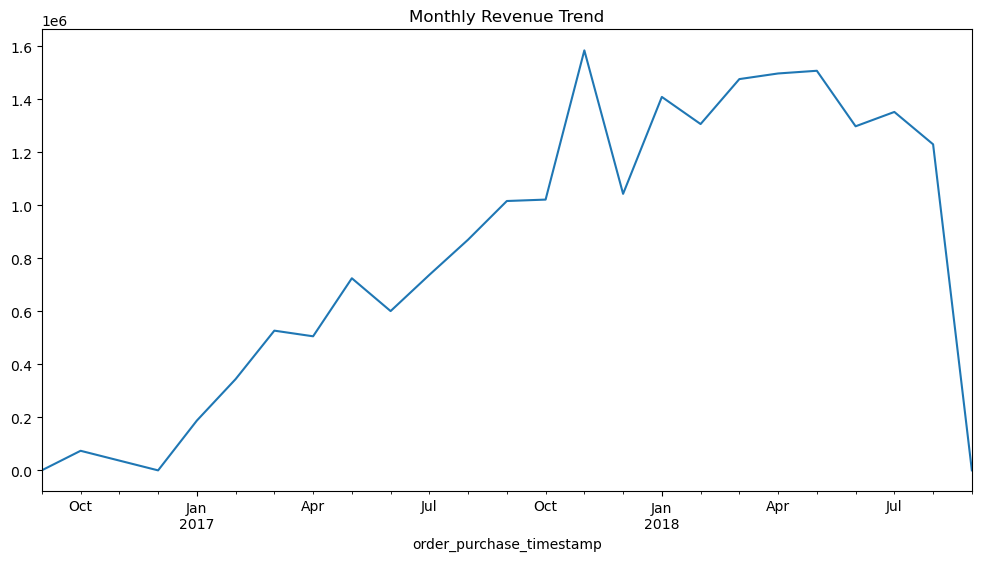

In [22]:
import matplotlib.pyplot as plt

monthly_revenue.plot(figsize=(12,6))
plt.title('Monthly Revenue Trend')
plt.show()

## Revenue by State

In [25]:
state_revenue = df.groupby(
    'customer_state'
)['payment_value'].sum().sort_values(
    ascending=False
)

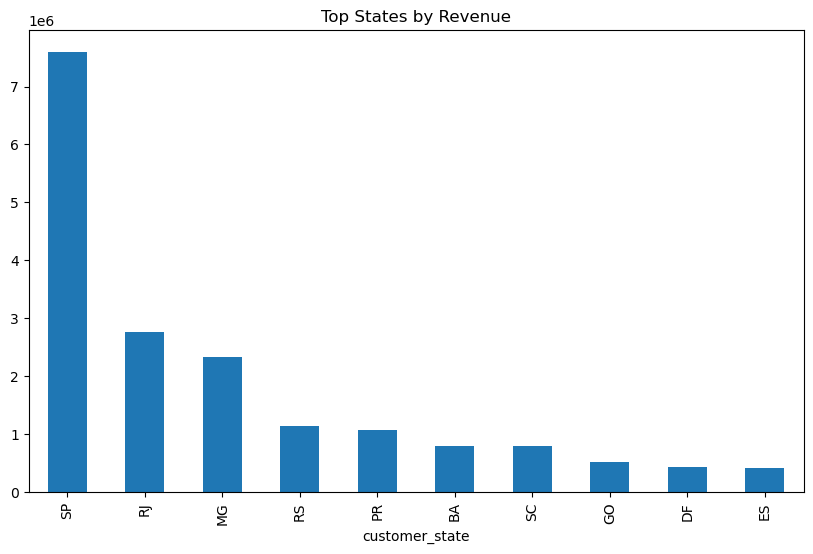

In [27]:
state_revenue.head(10).plot(
    kind='bar',
    figsize=(10,6)
)
plt.title('Top States by Revenue')
plt.show()

## Top Product Categories

In [30]:
category_translation = pd.read_csv(
    r"C:\Users\raabh\Downloads\archive (16)\product_category_name_translation.csv"
)

## Customer Analysis

In [33]:
top_customers = df.groupby(
    'customer_unique_id'
)['payment_value'].sum().sort_values(
    ascending=False
)

## Delivery Analysis

In [38]:
import pandas as pd

# Convert columns to datetime
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

orders['order_delivered_customer_date'] = pd.to_datetime(
    orders['order_delivered_customer_date']
)

orders['order_estimated_delivery_date'] = pd.to_datetime(
    orders['order_estimated_delivery_date']
)

In [40]:
orders['delivery_days'] = (
    orders['order_delivered_customer_date']
    - orders['order_purchase_timestamp']
).dt.days

In [42]:
orders[['order_purchase_timestamp',
        'order_delivered_customer_date',
        'delivery_days']].head()

,order_purchase_timestamp,order_delivered_customer_date,delivery_days
0,2017-10-02 10:56:33,2017-10-10 21:25:13,8.0
1,2018-07-24 20:41:37,2018-08-07 15:27:45,13.0
2,2018-08-08 08:38:49,2018-08-17 18:06:29,9.0
3,2017-11-18 19:28:06,2017-12-02 00:28:42,13.0
4,2018-02-13 21:18:39,2018-02-16 18:17:02,2.0


### Average Delivery

In [44]:
avg_delivery = orders['delivery_days'].mean()

print(f"Average Delivery Time: {avg_delivery:.2f} days")

Average Delivery Time: 12.09 days


### Fastest and Slowest Delivery

In [46]:
print("Fastest Delivery:",
      orders['delivery_days'].min(),
      "days")

print("Slowest Delivery:",
      orders['delivery_days'].max(),
      "days")

Fastest Delivery: 0.0 days
Slowest Delivery: 209.0 days


### Delivery Time Statistics

In [48]:
orders['delivery_days'].describe()

count    96476.000000
mean        12.094086
std          9.551746
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64

### Histogram of Delivery Times

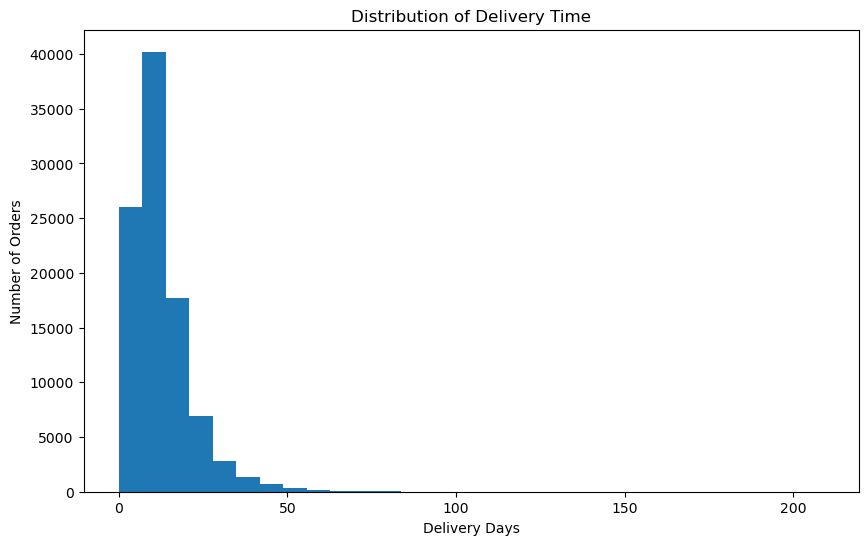

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(
    orders['delivery_days'],
    bins=30
)

plt.xlabel('Delivery Days')
plt.ylabel('Number of Orders')
plt.title('Distribution of Delivery Time')

plt.show()

### Find Delayed Orders

In [54]:
orders['delay_days'] = (
    orders['order_delivered_customer_date']
    - orders['order_estimated_delivery_date']
).dt.days

In [56]:
delayed_orders = orders[
    orders['delay_days'] > 0
]

print("Number of delayed orders:",
      delayed_orders.shape[0])

Number of delayed orders: 6535


### Percentage of Delayed Orders

In [58]:
delay_percentage = (
    delayed_orders.shape[0]
    / orders.shape[0]
) * 100

print(
    f"Delayed Orders Percentage: {delay_percentage:.2f}%"
)

Delayed Orders Percentage: 6.57%


### Merge with Customers

In [60]:
delivery_df = orders.merge(
    customers,
    on='customer_id'
)

### Average Delivery Time by State

In [62]:
state_delivery = (
    delivery_df
    .groupby('customer_state')['delivery_days']
    .mean()
    .sort_values(ascending=False)
)

print(state_delivery.head(10))

customer_state
RR    28.975610
AP    26.731343
AM    25.986207
AL    24.040302
PA    23.316068
MA    21.117155
SE    21.029851
CE    20.817826
AC    20.637500
PB    19.953578
Name: delivery_days, dtype: float64


### Visualization

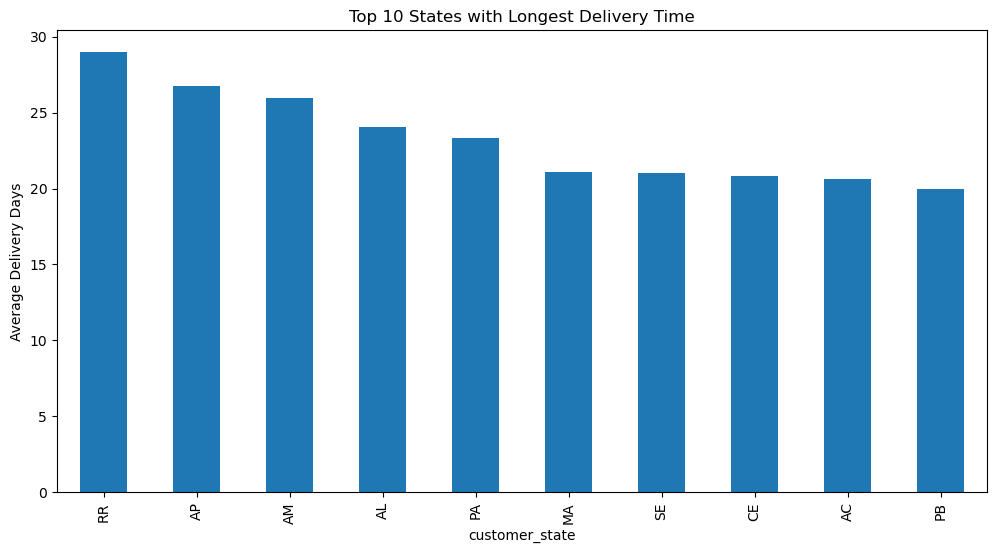

In [64]:
plt.figure(figsize=(12,6))

state_delivery.head(10).plot(
    kind='bar'
)

plt.ylabel('Average Delivery Days')
plt.title('Top 10 States with Longest Delivery Time')

plt.show()

# Product Analysis

In [76]:
category_translation = pd.read_csv(
    r"C:\Users\raabh\Downloads\archive (16)\product_category_name_translation.csv"
)

## Merge Product Information

In [79]:
product_df = (
    order_items
    .merge(products, on='product_id')
    .merge(category_translation, on='product_category_name')
    .merge(payments, on='order_id')
)

## Top Categories by Revenue

In [82]:
category_revenue = (
    product_df
    .groupby('product_category_name_english')['payment_value']
    .sum()
    .sort_values(ascending=False)
)

category_revenue.head(10)

product_category_name_english
bed_bath_table           1712553.67
health_beauty            1657373.12
computers_accessories    1585330.45
furniture_decor          1430176.39
watches_gifts            1429216.68
sports_leisure           1392127.56
housewares               1094758.13
auto                      852294.33
garden_tools              838280.75
cool_stuff                779698.00
Name: payment_value, dtype: float64

## Plot Top Categories

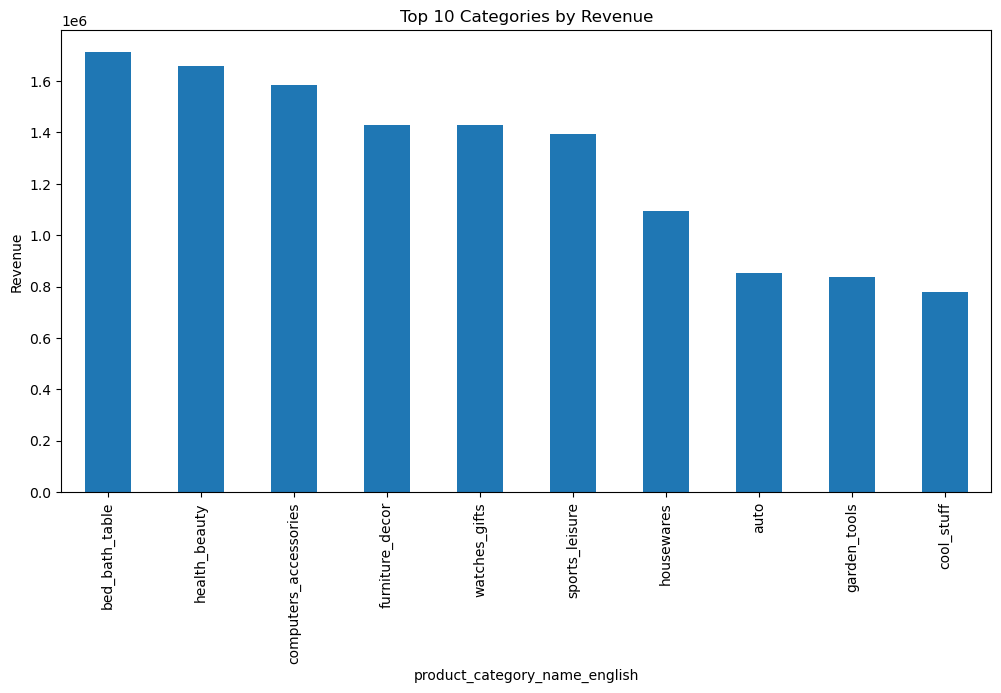

In [85]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

category_revenue.head(10).plot(kind='bar')

plt.title("Top 10 Categories by Revenue")
plt.ylabel("Revenue")

plt.show()

## Top Categories by Sales Volume

In [88]:
category_sales = (
    product_df
    .groupby('product_category_name_english')
    .size()
    .sort_values(ascending=False)
)

category_sales.head(10)

product_category_name_english
bed_bath_table           11823
health_beauty             9972
sports_leisure            8945
furniture_decor           8744
computers_accessories     8082
housewares                7355
watches_gifts             6201
telephony                 4721
garden_tools              4574
auto                      4379
dtype: int64

# Customer Analysis

## Top Customers

In [92]:
customer_revenue = (
    df.groupby('customer_unique_id')['payment_value']
    .sum()
    .sort_values(ascending=False)
)

customer_revenue.head(10)

customer_unique_id
0a0a92112bd4c708ca5fde585afaa872    109312.64
698e1cf81d01a3d389d96145f7fa6df8     45256.00
c402f431464c72e27330a67f7b94d4fb     44048.00
4007669dec559734d6f53e029e360987     36489.24
ef8d54b3797ea4db1d63f0ced6a906e9     30186.00
763c8b1c9c68a0229c42c9fc6f662b93     29099.52
c8460e4251689ba205045f3ea17884a1     27935.46
eae0a83d752b1dd32697e0e7b4221656     25051.89
3d47f4368ccc8e1bb4c4a12dbda7111b     22346.60
adfa1cab2b2c8706db21bb13c0a1beb1     19457.04
Name: payment_value, dtype: float64

## Revenue Distribution

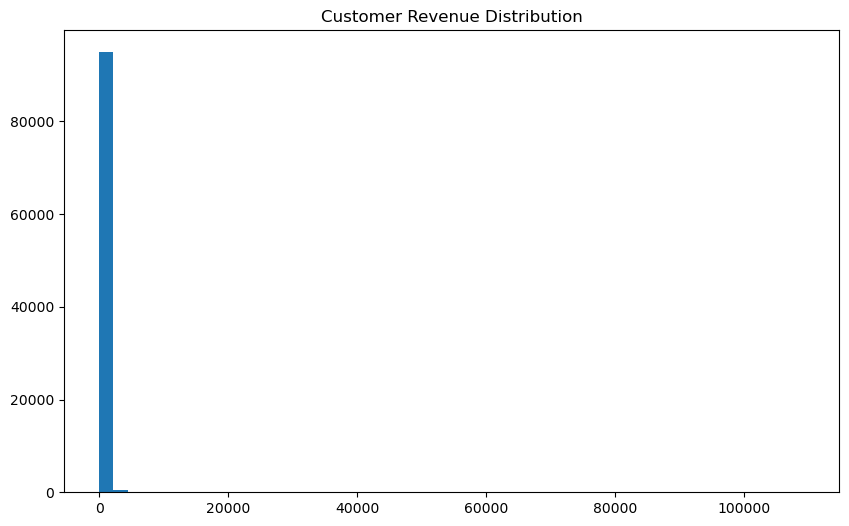

In [95]:
plt.figure(figsize=(10,6))

plt.hist(
    customer_revenue,
    bins=50
)

plt.title("Customer Revenue Distribution")
plt.show()

# Time-Series Analysis ⭐⭐⭐⭐⭐

## Convert Purchase Date

In [99]:
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

## Monthly revenue

In [102]:
monthly_revenue = (
    orders
    .merge(payments,on='order_id')
    .groupby(
        orders['order_purchase_timestamp'].dt.to_period('M')
    )['payment_value']
    .sum()
)

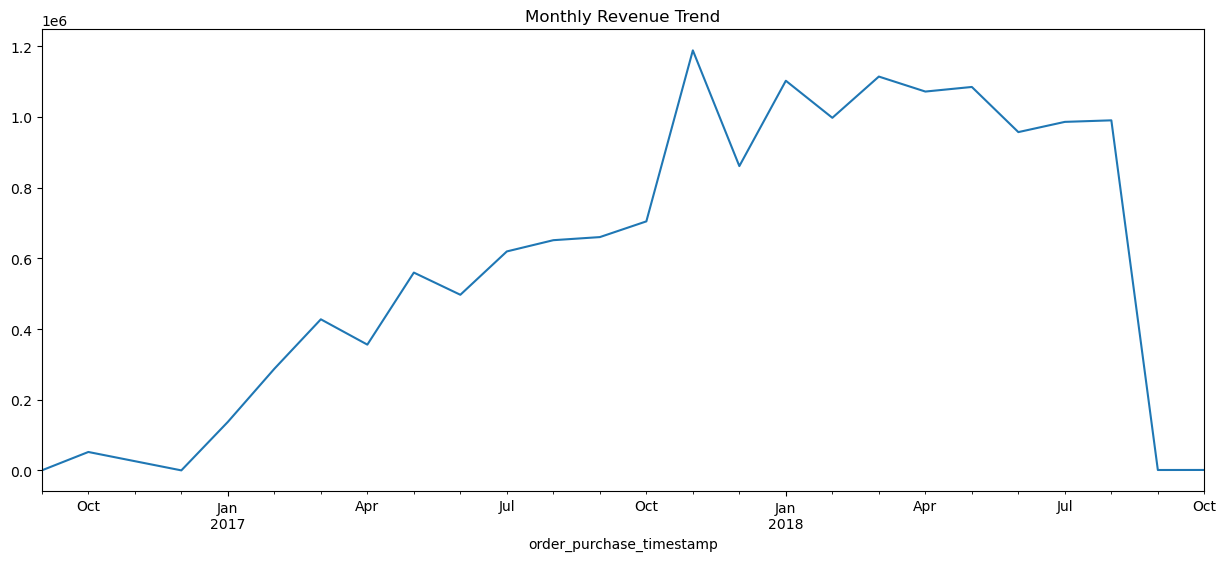

In [104]:
monthly_revenue.plot(figsize=(15,6))
plt.title("Monthly Revenue Trend")
plt.show()